# Cardiovascular Disease Prediction - Data Preprocessing

## Dataset
Cardiovascular Disease dataset (Kaggle), 70,000 patient records, 
11 clinical features + binary target (presence/absence of 
cardiovascular disease).

## Preprocessing Pipeline

**1. Feature cleanup**
- Dropped `id` column (no predictive value)
- Converted `age` from days to years (rounded to nearest integer)

**2. Exploratory Data Analysis**
- Visualized age distribution, height vs weight relationships, 
  and feature correlations via correlation matrix
- Identified `age` (0.24) and `cholesterol` (0.22) as the 
  strongest individual predictors of cardiovascular disease

**3. Data quality - outlier removal**
- Identified physically implausible values during EDA (e.g., 
  height of 250cm, blood pressure readings of 16000)
- Removed ~1,324 rows (1.9%) with implausible height, weight, 
  systolic (ap_hi), or diastolic (ap_lo) blood pressure values
- Final dataset: 68,676 rows before scaling

**4. Feature analysis**
- Grouped analysis on cholesterol levels showed clear gradient: 
  44% / 60% / 77% prevalence of cardiovascular disease across 
  normal / above-normal / well-above-normal cholesterol groups
- Confirmed balanced target classes (49.97% / 50.03%) so no class 
  imbalance correction needed

**5. Feature scaling**
- Applied Min-Max scaling (0-1 range) to age, height, weight, 
  ap_hi, ap_lo using scikit-learn's MinMaxScaler
- Saved scaling parameters for consistent transformation of 
  future inference inputs

## Output
Cleaned, scaled dataset exported to S3 (`cardio_cleaned.csv`), 
ready for model training (XGBoost) using AWS

In [1]:
import pandas as pd
import boto3
import matplotlib.pyplot as plt

df = pd.read_csv('s3://cardiovasculardata/cardio_train.csv', sep=';')
print(df.shape)
df.head()

(70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [2]:
df = df.drop('id', axis=1)
df.shape

(70000, 12)

In [3]:
df['age'] = (df['age'] / 365).round().astype(int)
df['age'].head()

0    50
1    55
2    52
3    48
4    48
Name: age, dtype: int64

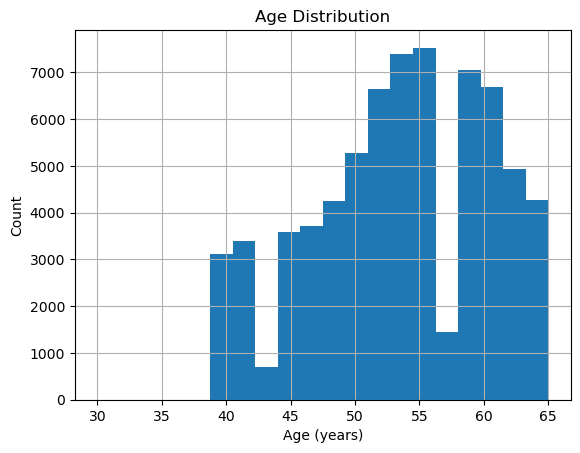

In [4]:
df['age'].hist(bins=20)
plt.title('Age Distribution')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.show()

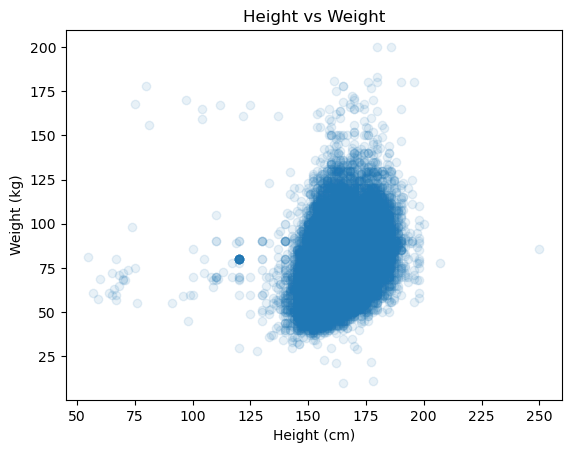

In [5]:
plt.scatter(df['height'], df['weight'], alpha=0.1)
plt.title('Height vs Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

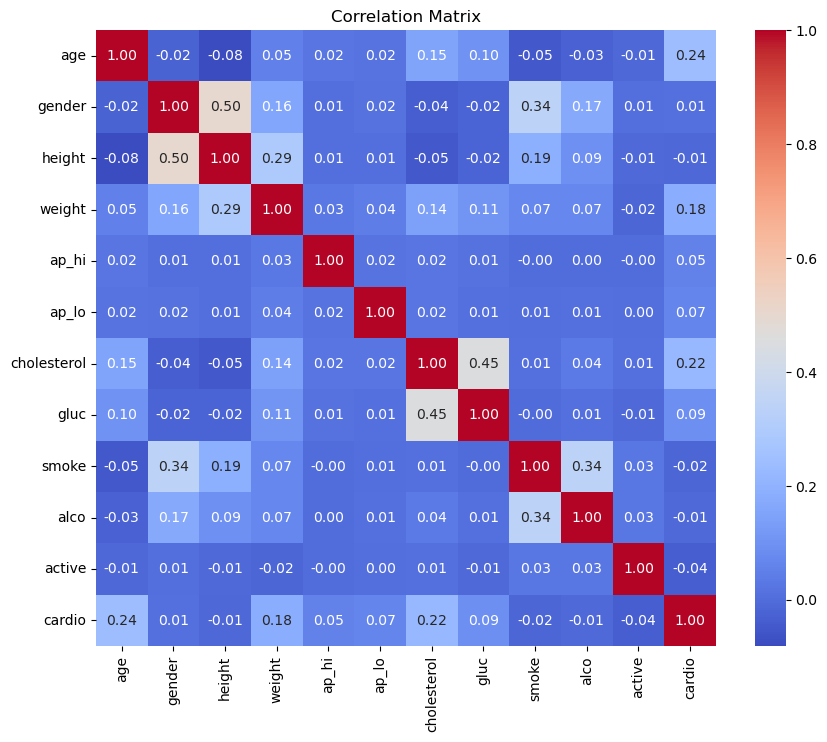

In [6]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [7]:
df.groupby('cholesterol')['cardio'].mean()

cholesterol
1    0.440107
2    0.602157
3    0.765435
Name: cardio, dtype: float64

In [8]:
df['cardio'].value_counts(normalize=True)

cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64

In [9]:
'''
Outlier removal: Dropped 45/70000 rows (~0.06%) with implausible height (<100 or >220cm) 
or weight (<30 or> 200 kg), found via scatter plot during EDA.
Why: Min-max scaling uses column min/max - one extreme outlier compresses all 
normal values toward 0, hurting the model's ability to distinguish typical 
patients.
'''

print(f"Before: {df.shape}")

df = df[(df['height'] > 100) & (df['height'] < 220)]
df = df[(df['weight'] > 30) & (df['weight'] < 200)]
df = df[(df['ap_hi'] > 70) & (df['ap_hi'] < 250)]
df = df[(df['ap_lo'] > 40) & (df['ap_lo'] < 150)]

print(f"After: {df.shape}")

Before: (70000, 12)
After: (68676, 12)


In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols_to_scale = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

df[cols_to_scale].describe()

,age,height,weight,ap_hi,ap_lo
count,68676.000000,68676.000000,68676.000000,68676.000000,68676.000000
mean,0.666504,0.586408,0.283698,0.291440,0.382683
std,0.193331,0.077324,0.093995,0.104487,0.099985
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.514286,0.533981,0.223684,0.250000,0.368421
50%,0.685714,0.592233,0.269737,0.250000,0.368421
75%,0.800000,0.640777,0.335526,0.375000,0.473684
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
print("ap_hi range:", scaler.data_min_[3], "to", scaler.data_max_[3])
print("ap_lo range:", scaler.data_min_[4], "to", scaler.data_max_[4])

ap_hi range: 80.0 to 240.0
ap_lo range: 45.0 to 140.0


In [12]:
df.to_csv('s3://cardiovasculardata/cardio_cleaned.csv', index=False)
print("Saved successfully")
print(df.shape)

Saved successfully
(68676, 12)


## Phase 2: Train/Test Split & Formatting

- Split data 80/20 (54,940 train / 13,736 test rows), 
  random_state=42 for reproducibility
- Reformatted for SageMaker's built-in XGBoost: target column 
  (cardio) first, followed by 11 features, no header row, no index
- Uploaded train.csv and test.csv to S3 (data/train/, data/test/)

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (54940, 11)
Test size: (13736, 11)


In [14]:
train_data = pd.concat([y_train, X_train], axis=1)
test_data = pd.concat([y_test, X_test], axis=1)

train_data.head()

,cardio,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
23045,1,0.914286,2,0.660194,0.519737,0.3125,0.368421,3,1,0,0,1
24739,0,0.685714,2,0.592233,0.217105,0.1875,0.368421,1,1,1,0,1
47126,0,0.428571,1,0.504854,0.315789,0.3125,0.473684,1,1,0,0,1
63931,1,0.457143,2,0.660194,0.493421,0.3750,0.473684,2,1,1,1,1
6724,1,0.657143,1,0.631068,0.309211,0.2500,0.368421,1,2,0,0,0


In [15]:
train_data.to_csv('train.csv', index=False, header=False)
test_data.to_csv('test.csv', index=False, header=False)

s3 = boto3.client('s3')
bucket = 'cardiovasculardata'

s3.upload_file('train.csv', bucket, 'data/train/train.csv')
s3.upload_file('test.csv', bucket, 'data/test/test.csv')

print("Uploaded successfully")

Uploaded successfully
